## <font color='##3B9C9C'>Projeto #2: Análise dos dados de customer churn do banco na Bélgica</font>
_______________________________________________________________________________________________

As análises que você fez até aqui para as sedes do banco na França, Espanha, Alemanha e Portugal ficaram muito boas. A forma como você comunicou os resultados de forma objetiva e fácil para os demais colaboradores não-técnicos do banco entenderem, bem como o nível de detalhes que você adicionou no material final despertaram o **interesse do time de CRM da Bélgica em entender o perfil dos clientes que estão deixando de utilizar os serviços do banco no país**.

Assim como você incorporou os dados de Portugal na análise anterior, você precisará adicionar os dados de *customer churn* da Bélgica (**`.dados/Customer-Churn-Records-Belgium.csv`**) e considerar os dados de cidades dos clientes do país (**`./dados/Customer-Counties-Belgium.csv`**). A adição dos gráficos em uma apresentação é opcional, no entanto, você deverá plotar os gráficos e sumarizar os dados de rotatividade considerando todos os 5 países juntos, assim como foi feito na etapa anterior com os quatro países.

A equipe do banco na Bélgica precisa da sua ajuda para responder as seguintes perguntas de negócio:

##### Como está a taxa de rotatividade média da Bélgica comparada aos demais países?
##### Qual o perfil dos clientes belgas que estão deixando de utilizar os serviços do banco?
<br/><br/>

🛠️ **Assistência nas análises**

Você pode escolher o nível de assistência em que se sinta mais confortável entre os 3 disponíveis durante a execução da sua análise:

1. **Nível 1**: Notebook contendo as requisições do que deve ser feito, com a maior parte do código já estruturada, mas **faltando algumas partes chaves para preenchimento**, como nomes de funções, argumentos, etc.
3. **Nível 2**: Notebook contendo o passo a passo de como poder ser feito, mas **faltando as linhas de códigos**.
5. **Nível 3**: Notebook contendo somente com as perguntas de negócio, mas **sem nenhum código ou passo a passo de como pode ser feito**.

Lembre-se! O sucesso do seu aprendizado não está no nível em que você realizará as análises, mas no que você agora é capaz de desenvolver e não era antes de iniciar esse curso.

⚠️ **Lembretes Importantes!**
- Ao juntar os dados da Bélgica, lembre-se de utilizar como base o arquivo final em csv que você gerou com os quatro países (**`./dados/Customer-Churn-Records_FR-GE-ES-PT.csv`**), já incluindo Portugal.

💻 **Datasets a serem utilizados**
- **`.dados/Customer-Churn-Records-Belgium.csv`**
- **`./dados/Customer-Counties-Belgium.csv`**
- **`./dados/Customer-Churn-Records_FR-GE-ES-PT.csv`**

✅ **Durante a execução das análises, responda as seguintes perguntas:**

1. Qual variável tem a maior correlação com a variável Exited?
2. Quais as 3 cidades com as maiores taxas de rotatividade?
3. Qual a taxa de rotatividade do banco na Bélgica e quanto a mais isso representa em relação a Portugal?
4. O grupo de clientes com idades entre 35-45 anos é o mais representativo com um total de ( ) clientes. No entanto, o grupo com maior taxa de rotatividade é o grupo de clientes com menos de 35 anos cuja taxa de rotatividade é de ( )%.
5. Qual a diferença de salário estimado entre os clientes que saíram e permaneceram no banco da Bélgica?


**Bom trabalho!**

#### Importa os datasets e concatena

In [1]:
# PASSO A PASSO:
# Este bloco executa uma etapa específica da análise.
# Leia os comentários e entenda o objetivo antes de rodar.

## Importa dependências
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Importa os dados

### TO DO: Leia o dataframe principal com os clientes da França, Alemanha, Portugal e Espanha
df_almost_full = pd.read_csv('Customer-Churn-Records_FR-GE-PT-ES.csv')

### TO DO: Leia o novo dataframe com os dados dos clientes da Bélgica
df_belgium = pd.read_csv('Customer-Churn-Records-Belgium.csv')

### TO DO: Leia o novo dataframe com as cidades dos clientes da Bélgica
df_belgium_cities = pd.read_csv('Customer-Counties-Belgium.csv')


In [2]:
df_belgium.shape

(884, 18)

In [4]:
df_belgium.columns

Index(['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography',
       'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Exited', 'Complain',
       'Satisfaction Score', 'Card Type', 'Point Earned'],
      dtype='object')

In [3]:
df_belgium_cities.shape

(883, 3)

In [5]:
df_belgium_cities.columns

Index(['CustomerId', 'Geography', 'County'], dtype='object')

In [ ]:
#df_belgium = df_belgium.drop(['RowNumber','Surname'], axis=1) ou  df_belgium.drop(columns = ['RowNumber','Surname'])
df_belgium.shape

(884, 16)

In [10]:
df_belgium = df_belgium.drop_duplicates()

In [12]:
df_belgium = df_belgium.dropna()
df_belgium.shape

(884, 16)

In [13]:
df_belgium_cities = df_belgium_cities.drop_duplicates()
df_belgium_cities = df_belgium_cities.dropna()

In [14]:
df_belgium_cities.shape

(883, 3)

In [16]:
### TO DO: Faça o merge do dataframe de cidades no dataframe dos clientes da Bélgica 
df_belgium_full = pd.merge(df_belgium, df_belgium_cities, on='CustomerId', how='left')
df_belgium_full.head(3)

,CustomerId,CreditScore,Geography_x,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction Score,Card Type,Point Earned,Geography_y,County
0,18769397,545,Belgium,Female,33,3,191150.312178,1,False,False,67925.669111,True,False,0,GOLD,488.030278,Belgium,Liège
1,18659339,621,Belgium,Female,29,3,168518.331692,1,True,False,47403.875845,True,False,3,SILVER,518.103104,Belgium,Brussels
2,18612046,606,Belgium,Male,47,6,103315.853394,1,True,False,51596.327861,True,False,5,DIAMOND,498.331838,Belgium,Brussels


In [27]:
df_almost_full.columns

Index(['CustomerId', 'Surname', 'CreditScore', 'Geography', 'Gender', 'Age',
       'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember',
       'EstimatedSalary', 'Exited', 'Complain', 'Satisfaction Score',
       'Card Type', 'Point Earned', 'County'],
      dtype='object')

In [28]:
df_belgium_full.columns

Index(['CustomerId', 'CreditScore', 'Geography_x', 'Gender', 'Age', 'Tenure',
       'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember',
       'EstimatedSalary', 'Exited', 'Complain', 'Satisfaction Score',
       'Card Type', 'Point Earned', 'Geography_y', 'County'],
      dtype='object')

In [34]:
#df_belgium_full = df_belgium_full.drop(columns='Geography_y')
df_belgium_full = df_belgium_full.rename({'Geography_x': 'Geography'},axis=1)
#df_almost_full = df_almost_full.drop(columns='Surname')

In [35]:
df_belgium_full.columns

Index(['CustomerId', 'CreditScore', 'Geography', 'Gender', 'Age', 'Tenure',
       'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember',
       'EstimatedSalary', 'Exited', 'Complain', 'Satisfaction Score',
       'Card Type', 'Point Earned', 'County'],
      dtype='object')

In [36]:
df_almost_full.columns

Index(['CustomerId', 'CreditScore', 'Geography', 'Gender', 'Age', 'Tenure',
       'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember',
       'EstimatedSalary', 'Exited', 'Complain', 'Satisfaction Score',
       'Card Type', 'Point Earned', 'County'],
      dtype='object')

In [17]:
df_belgium_full.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 884 entries, 0 to 883
Data columns (total 18 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   CustomerId          884 non-null    int64  
 1   CreditScore         884 non-null    int64  
 2   Geography_x         884 non-null    object 
 3   Gender              884 non-null    object 
 4   Age                 884 non-null    int64  
 5   Tenure              884 non-null    int64  
 6   Balance             884 non-null    float64
 7   NumOfProducts       884 non-null    int64  
 8   HasCrCard           884 non-null    bool   
 9   IsActiveMember      884 non-null    bool   
 10  EstimatedSalary     884 non-null    float64
 11  Exited              884 non-null    bool   
 12  Complain            884 non-null    bool   
 13  Satisfaction Score  884 non-null    int64  
 14  Card Type           884 non-null    object 
 15  Point Earned        884 non-null    float64
 16  Geograph

In [5]:
### TO DO: Remova a coluna RowNumber


In [6]:
### TO DO: Visualize as 5 primeiras linhas do dataframe da Bélgica


In [7]:
### TO DO: Certifique-se de que não tem nenhum cliente sem dados de cidade


In [ ]:
### TO DO: Certifique-se de que os dataframes de clientes da Bélgica 
### e demais países têm as mesmas colunas


In [38]:
df_belgium_full.shape

(884, 17)

In [39]:
df_almost_full.shape

(10568, 17)

In [37]:
### TO DO: Concatene os dois dataframes (Bélgica e demais países)
df_main = pd.concat([df_almost_full, df_belgium_full])
df_main.head(3)

,CustomerId,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction Score,Card Type,Point Earned,County
0,15737173,474.637955,Spain,Male,38,3,68990.682014,2,True,False,42856.316169,True,False,3,GOLD,578.682607,Madrid
1,15597945,522.650461,Spain,Female,37,8,55484.615047,2,True,False,41939.810698,True,False,2,DIAMOND,590.088891,Bilbao
2,15625047,550.825497,France,Female,37,5,55645.820270,1,True,True,37326.078597,True,False,3,PLATINUM,682.831504,Toulouse


In [40]:
df_main.shape

(11452, 17)

In [10]:
### TO DO: Visualize os valores únicos na coluna Geography 
### para garantir que os dados da Bélgica foram adicionados


#### Gere um heatmap com a matriz de correlação entre as variáveis numéricas considerando somente a Bélgica

Sugestões - você pode:
- utilizar as funções query ou loc para filtrar o dataframe
- gerar um gráfico de correlação entre as variáveis
- usar o parâmetro de anotação com a correlação entre as variáveis

In [12]:
### TO DO: Crie um novo dataframe somente com os clientes da Bélgica 


In [13]:
### TO DO: Crie uma lista com os nomes das colunas do tipo inteiro, float ou booleana


In [14]:
### TO DO: Crie um novo dataframe contendo somente essas colunas definidas anteriormente


In [15]:
### TO DO: Arredonde todos os valores para 2 casas decimais


In [16]:
### TO DO: Crie uma matriz de correlação a partir desse dataframe criado


In [17]:
### TO DO: Crie uma matriz de máscara superior


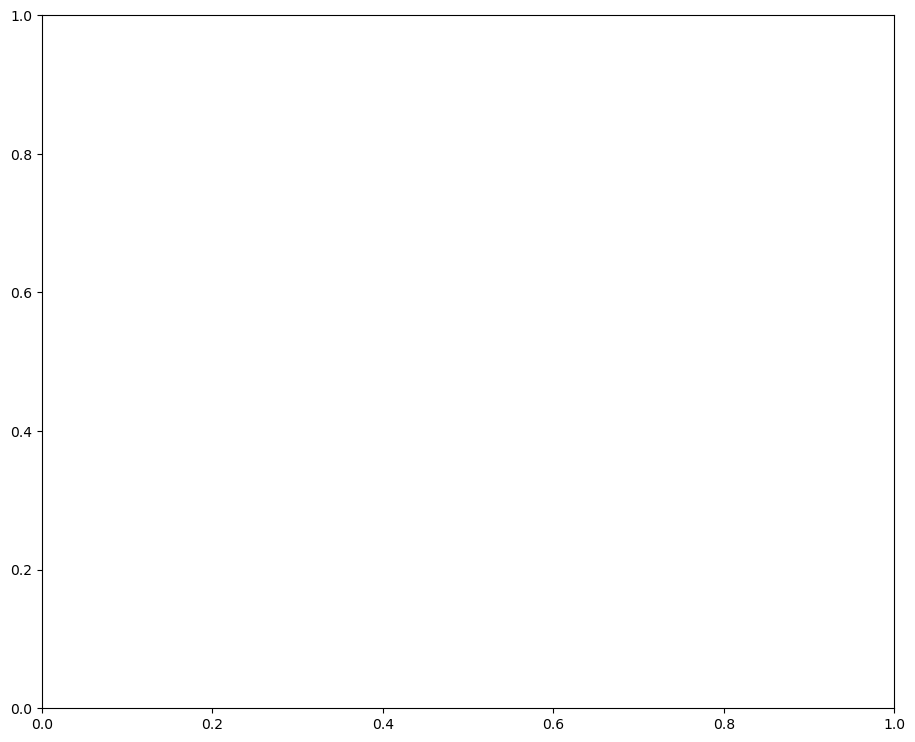

In [18]:

# Cria o gradiente de cores para o gráfico
cmap = sns.diverging_palette(20, 230, as_cmap=True)

# Cria o objeto da figura com tamanho específico
f, ax = plt.subplots(figsize=(11, 9))

### TO DO: Crie o heatmap a partir da matriz de correlação

### TO DO: Adicione um título para o gráfico

### TO DO: Plote o gráfico


##### <font color='#E41B17'>❓ Pergunta: </font> Qual variável tem a maior correlação com a variável Exited?<font color='#52595D'>

##### <font color='blue'> Resposta: </font> 

#### Quais são as 3 cidades com maior taxa de rotatividade e o percentual de cada?
- Plote um gráfico com a rotatividade média entre cidades
- Crie uma tabela agrupada com a média da rotatividade entre cidades

In [22]:
### TO DO: Utilize o mesmo racional para criar um dataframe com o 
### total de clientes e rotatividade média agrupados por país e cidade


In [23]:
### TO DO: Visualize esse dataframe criado


In [24]:
### TO DO: Crie um gráfico de barras horizontal utilizando o dataframe criado. No eixo y são os países e no eixo x a taxa de rotatividade


##### <font color='#E41B17'>❓ Pergunta: </font> Quais as 3 cidades com as maiores taxas de rotatividade?<font color='#52595D'>

##### <font color='blue'> Resposta: </font> 

#### Qual a taxa de rotatividade média na Bélgica?
- Plote um gráfico com a rotatividade média entre países
- Crie uma tabela agrupada com a média da rotatividade entre países

In [28]:
### TO DO: A partir do dataframe com todos os países, crie um dataframe com o 
### total de clientes e rotatividade média agrupados por país


In [29]:
### TO DO: Visualize esse dataframe criado


In [30]:
### TO DO: Crie um gráfico de barras utilizando o dataframe criado. No eixo x são os países e no eixo y a taxa de rotatividade


##### <font color='#E41B17'>❓ Pergunta: </font> Qual a taxa de rotatividade do banco na Bélgica e quanto a mais isso representa em relação a Portugal?<font color='#52595D'>

##### <font color='blue'> Resposta: </font>

#### Qual grupo de idade (<35 anos, 35 - 45 anos, 45 - 55 anos, >55 anos) tem o maior número de clientes? E qual grupo tem a maior taxa de rotatividade?
- Crie um gráfico de barras, linhas ou outro de sua preferência para visualizar os dados e sumarize os dados para obter os valores das médias.

In [34]:
### TO DO: Crie uma variável categórica com os seguintes grupos de idade: '<35', '35-45', '45-55', '>55'.


In [35]:
### TO DO: Crie um dataframe com o total de saídas do banco

In [36]:
### TO DO: Crie um dataframe com o total de clientes, saídas e taxa de rotatividade média do banco por grupo de idade. 


In [37]:
### TO DO: Visualize o dataframe criado anteriormente


In [38]:
### TO DO: Crie um gráfico de barras com o total de clientes (eixo y) por grupo de idade (eixo x)


In [39]:
### TO DO: Crie um gráfico de barras com a taxa de rotatividade média (eixo y) por grupo de idade (eixo x)


##### <font color='#E41B17'>❓ Pergunta: <font color='#52595D'>Preencha os dados faltantes nessa afirmação (Número inteiro sem casas decimais):
O grupo de clientes com idades entre 35-45 anos é o mais representativo com um total de __(   )__ clientes. No entanto, o grupo com maior taxa de rotatividade é o grupo de clientes com menos de 35 anos cuja taxa de rotatividade é de __(  )__%.

##### <font color='blue'> Resposta: </font> 

#### Qual a diferença da média salarial entre quem saiu e permaneceu no banco da Bélgica

- Crie um gráfico boxplot ou gráfico de distribuição
- Crie uma tabela agrupada com médias dos dois grupos

In [43]:
### TO DO: Crie um gráfico boxplot do Salário Estimado entre os 
### grupos de clientes que saíram e permaneceram no banco da Bélgica

In [44]:
### TO DO: Crie um dataframe com a média do salário estimado 
### entre os grupos de quem permaneceu e saiu do banco da Bélgica


In [45]:
### TO DO: Visualize o dataframe criado


##### <font color='#E41B17'>❓ Pergunta: <font color='#52595D'> Qual a diferença de salário estimado entre os clientes que saíram e permaneceram no banco da Bélgica?

##### <font color='blue'> Resposta: </font>